In [1]:
# ---------------------------------------
# Importação de bibliotecas
# ---------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta

np.random.seed(42)

In [2]:
# ---------------------------------------
# Geração de base simulada de leads
# ---------------------------------------

n = 1000

origens = ["Instagram", "Google Ads", "Indicação", "Site", "OLX"]
etapas = ["Lead", "Contato realizado", "Visita agendada", "Proposta enviada", "Fechado", "Perdido"]

dados = []

for i in range(n):

    origem = random.choice(origens)

    data_entrada = datetime(2025, 1, 1) + timedelta(days=random.randint(0, 180))

    valor_imovel = random.randint(300000, 1500000)

    prob_fechamento = {
        "Instagram": 0.08,
        "Google Ads": 0.12,
        "Indicação": 0.25,
        "Site": 0.10,
        "OLX": 0.05
    }

    fechado = np.random.rand() < prob_fechamento[origem]

    if fechado:
        etapa = "Fechado"
    else:
        etapa = random.choice(etapas[:-1])

    dados.append([i, origem, data_entrada, etapa, valor_imovel, fechado])

df = pd.DataFrame(dados, columns=[
    "lead_id", "origem", "data_entrada", "etapa", "valor_imovel", "fechado"
])

df.head()

,lead_id,origem,data_entrada,etapa,valor_imovel,fechado
0,0,OLX,2025-01-20,Contato realizado,516070,False
1,1,Google Ads,2025-05-08,Lead,1130236,False
2,2,Google Ads,2025-01-04,Proposta enviada,1444094,False
3,3,Indicação,2025-02-28,Contato realizado,891588,False
4,4,Instagram,2025-01-27,Fechado,788232,False


In [4]:
df.to_csv("leads_imobiliaria.csv", index=False)

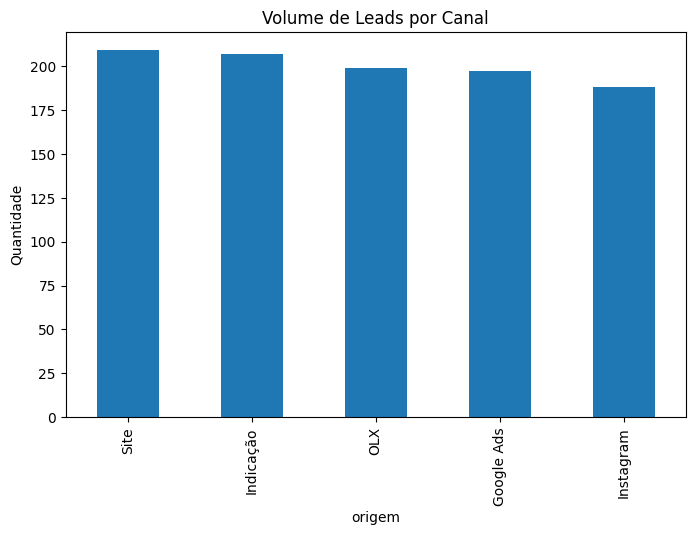

In [5]:
leads_por_canal = df["origem"].value_counts()

plt.figure(figsize=(8,5))
leads_por_canal.plot(kind="bar")
plt.title("Volume de Leads por Canal")
plt.ylabel("Quantidade")
plt.show()

In [6]:
taxa_conversao = df["fechado"].mean() * 100
print(f"Taxa de conversão geral: {taxa_conversao:.2f}%")

Taxa de conversão geral: 13.00%


In [7]:
conversao_canal = df.groupby("origem")["fechado"].mean() * 100
print(conversao_canal.sort_values(ascending=False))

origem
Indicação     23.188406
Google Ads    16.243655
Site          11.004785
Instagram      9.574468
OLX            4.522613
Name: fechado, dtype: float64


In [8]:
receita_total = df[df["fechado"] == True]["valor_imovel"].sum()
ticket_medio = df[df["fechado"] == True]["valor_imovel"].mean()

print(f"Receita total gerada: R$ {receita_total:,.2f}")
print(f"Ticket médio: R$ {ticket_medio:,.2f}")

Receita total gerada: R$ 119,647,532.00
Ticket médio: R$ 920,365.63


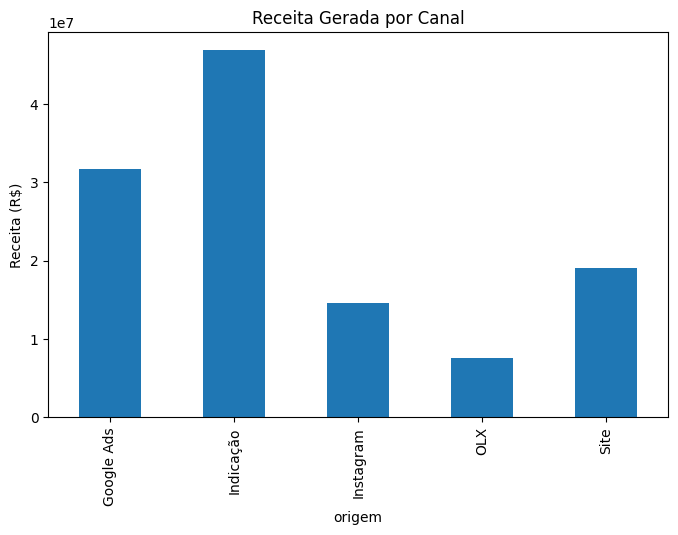

In [9]:
receita_por_canal = df[df["fechado"] == True].groupby("origem")["valor_imovel"].sum()

plt.figure(figsize=(8,5))
receita_por_canal.plot(kind="bar")
plt.title("Receita Gerada por Canal")
plt.ylabel("Receita (R$)")
plt.show()

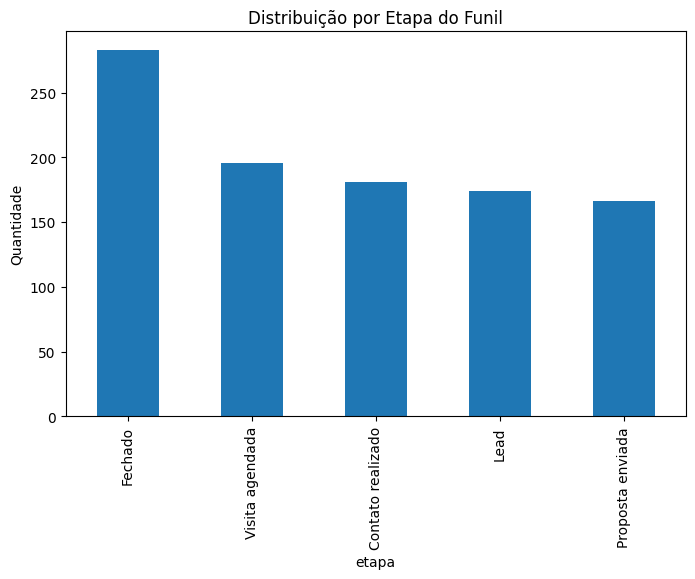

In [10]:
funil = df["etapa"].value_counts()

plt.figure(figsize=(8,5))
funil.plot(kind="bar")
plt.title("Distribuição por Etapa do Funil")
plt.ylabel("Quantidade")
plt.show()

In [11]:
melhor_canal = conversao_canal.idxmax()

leads_melhor = leads_por_canal[melhor_canal]
conversao_melhor = conversao_canal[melhor_canal] / 100

leads_projetados = int(leads_melhor * 1.2)
fechamentos_estimados = leads_projetados * conversao_melhor
receita_estimada = fechamentos_estimados * ticket_medio

print(f"Canal mais eficiente: {melhor_canal}")
print(f"Receita estimada com +20% investimento: R$ {receita_estimada:,.2f}")

Canal mais eficiente: Indicação
Receita estimada com +20% investimento: R$ 52,927,693.09


In [15]:
with pd.ExcelWriter("relatorio_funil.xlsx") as writer:
    df.to_excel(writer, sheet_name="Base_Completa", index=False)
    conversao_canal.to_excel(writer, sheet_name="Conversao_por_Canal")
    receita_por_canal.to_excel(writer, sheet_name="Receita_por_Canal")

print("Arquivo exportado com sucesso!")

Arquivo exportado com sucesso!


In [16]:
from google.colab import files
files.download("relatorio_funil.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>